# An autonomous NV-centre sensor: deviations from self-oscillation as the measurement signal

Demonstration for the work package "Use of deviations from autonomous behaviour as signals of external perturbations for quantum sensing devices", implemented on the existing CW ODMR setup (SMCV100B + Red Pitaya,
FM lock-in with virtual demodulation at a fixed 5 kHz, no phase reference).

## The idea in one paragraph

Our frequency-locked NV magnetometer is, viewed as a dynamical system, whose oscillatory behaviour is determined by its gain. Each lock cycle applies the discrete map `f_{k+1} = f_k − (G/D_cal)·[R(f_k) − R_0]`, whose linearisation has multiplier `1 − G_eff` with the dimensionless gain `G_eff = G·D_true/D_cal` proportional to the local slope of the ODMR lock-in lobe. For `G_eff < 2` the loop is an ordinary
tracker; at `G_eff = 2` it undergoes a **flip (period-doubling) bifurcation** and
becomes a **self-oscillator** — a limit cycle generated entirely by the device,
with no external clock or drive, cascading to chaos at higher gain (fig. 2). The
device's *deviation from* or *onset of* autonomous behaviour is then used as the
sensor output, in direct analogy with the proposal's programme: what the
Josephson bifurcation amplifier does for superconducting circuits, this loop does
for a room-temperature spin ensemble.

## What is sensed, and by which observable

| Observable of the autonomous device | Physical quantity it senses | Why |
|---|---|---|
| Mean of the locked/oscillating orbit | Uniform magnetic field (DC) | Shift symmetry: a uniform field only translates the resonance; the loop re-centres. Ordinary magnetometry survives. |
| **Onset of self-oscillation** (critical gain G_c) | **Slope-changing perturbations**: field **gradients** across the ensemble (inhomogeneous broadening), MW/laser power, temperature/linewidth | G_c = 2·D_cal/D_true; anything that reshapes the line moves the threshold (figs. 3, 4). A *differential* quantity, separated by symmetry from the uniform field — the NV analogue of the proposal's multi-weak-link gradient sensing. |
| Critical fluctuations below onset | Same as above, continuously | Loop noise gain diverges as 1/√(2 − G_eff): the fluctuation level is a precursor "susceptibility" measurement. |
| **Limit-cycle statistics** (cycle-amplitude envelope, two-time correlations) | **Time-periodic fields** above the loop bandwidth | The period-2 cycle acts as an *internal local oscillator*: an applied AC field appears as a mixing sideband in the demodulated cycle spectrum (fig. 5) — detected through second-order statistics, exactly the "two-time / n-time distribution functions" route of the proposal. |

## Correspondence with the proposal text

* *"Deviations from autonomous behaviour as signals of external perturbations"* —
  realised literally: the sensor output is the change in the loop's dynamical
  state (fixed point ↔ limit cycle ↔ chaos), not a calibrated analog voltage.
* *"The onset of the self-oscillating regime could be made dependent on a
  specific offset"* — the critical gain is set by the lobe slope; biasing G just
  below/above 2 makes the oscillation onset conditional on a chosen perturbation
  strength (fig. 4: a sharp P(oscillation) discriminator under realistic noise).
* *"Higher order statistical quantities such as the two-time or n-time
  distribution functions"* — periodic signals are read out from the two-time
  statistics of the limit cycle (fig. 5); the same analysis applies unchanged to
  the electron-emission statistics of the autonomous single-electron source.
* *"Differential quantities such as magnetic field gradients"* — by symmetry the
  threshold observable is blind to uniform fields and responds to gradients and
  other line-reshaping perturbations, mirroring the multi-weak-link Josephson
  refrigerator proposal.
* *"Comparison with NV centres"* — this demo **is** the NV benchmark platform,
  running today; every observable proposed for the SES/Josephson devices has a
  measured NV counterpart to compare against.

# Simulation
Here we simulate the system's behaviour, illustrating the effect of the opearting gain on the steady state frequency of the microwave generator.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(11)

# Parameters
HW      = 0.75        # ODMR half-width Gamma/2 [MHz]
RPK     = 0.010       # FM lobe peak [V] (as on the rig, ~10 mV)
SIG_R   = 3e-4        # readout noise per cycle [V] (~3 % of peak)
DT      = 0.05        # loop cycle time [s] (~20 cycles/s on the rig)
CLIP    = 8.0         # actuator range [MHz] (sweep-span clip)


def lobe(x, beta=0.0):
    """FM lock-in lobe |dL/df| for a Lorentzian of fixed contrast whose width
    is broadened by (1+beta). Positive x = detuning from the line centre."""
    hw = HW * (1.0 + beta)
    s = 2 * hw**2 * np.abs(x) / (x**2 + hw**2) ** 2
    s0 = 2 * HW**2 * (HW / np.sqrt(3)) / ((HW**2 / 3 + HW**2) ** 2)  # peak, beta=0
    return RPK * s / s0


# ---- calibration (done once, at beta = 0, like the real script) ----------
_xg = np.linspace(HW / np.sqrt(3), 6 * HW, 4000)          # outer flank
X0 = float(_xg[np.argmin(np.abs(lobe(_xg) - 0.45 * RPK))])  # setpoint: 45 % of peak
R0 = float(lobe(X0))
_d = 1e-5
D_CAL = float((lobe(X0 + _d) - lobe(X0 - _d)) / (2 * _d))   # V/MHz (<0)


def step(u, G, beta=0.0, noise=0.0):
    """One loop cycle: u is the detuning f - c."""
    R = lobe(u, beta) + noise
    return u - (G / D_CAL) * (R - R0)


def orbit(G, n=400, beta=0.0, sigma=0.0, u0=X0 + 0.05, rng=rng, drift=None):
    # note: u0 is seeded slightly OFF the fixed point, so an unstable lock
    # actually departs even in the noise-free (deterministic) runs
    """Iterate the map; returns the detuning trace. `drift` = per-step line-
    centre displacement array (enters as an equivalent detuning kick)."""
    u = np.empty(n)
    u[0] = u0
    for k in range(1, n):
        nz = sigma * rng.standard_normal() if sigma else 0.0
        u[k] = step(u[k - 1], G, beta, nz)
        if drift is not None:
            u[k] -= drift[k] - drift[k - 1]
        u[k] = np.clip(u[k], -CLIP, CLIP)
    return u


def orbit_amp(G, beta=0.0, sigma=0.0, n=600, keep=200, rng=rng):
    """Steady-state oscillation amplitude (std of the tail of the orbit)."""
    return float(np.std(orbit(G, n, beta, sigma, rng=rng)[-keep:]))

## Figures

C:\Users\Gonzalo\AppData\Local\Temp\ipykernel_23844\731373182.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


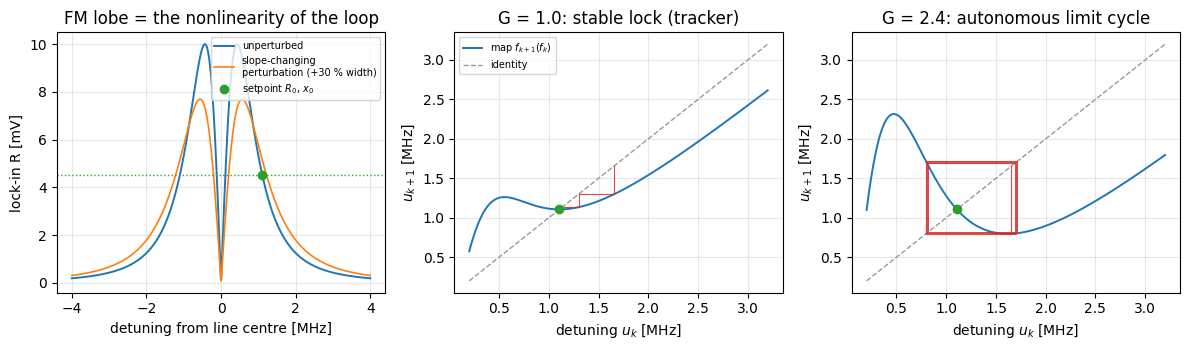

In [7]:
def cobweb(ax, G, n=40, u0=None):
    xs = np.linspace(0.2, 3.2, 600)
    ax.plot(xs, [step(x, G) for x in xs], color="C0", lw=1.4,
            label=r"map $f_{k+1}(f_k)$")
    ax.plot(xs, xs, color="0.6", lw=1, ls="--", label="identity")
    u = u0 if u0 is not None else X0 + 0.55
    px, py = [u], [u]
    for _ in range(n):
        v = step(u, G)
        px += [u, v]
        py += [v, v]
        u = v
    ax.plot(px, py, color="C3", lw=0.8, alpha=0.85)
    ax.plot(X0, X0, "o", color="C2", ms=6)
    ax.set(xlabel=r"detuning $u_k$ [MHz]", ylabel=r"$u_{k+1}$ [MHz]",
           title=f"loop gain G = {G}")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
x = np.linspace(-4, 4, 1200)
axes[0].plot(x, 1e3 * lobe(x), color="C0", lw=1.4, label="unperturbed")
axes[0].plot(x, 1e3 * lobe(x, 0.3), color="C1", lw=1.2,
             label="slope-changing\nperturbation (+30 % width)")
axes[0].axhline(1e3 * R0, color="C2", ls=":", lw=1)
axes[0].plot(X0, 1e3 * R0, "o", color="C2", label=rf"setpoint $R_0$, $x_0$")
axes[0].set(xlabel="detuning from line centre [MHz]", ylabel="lock-in R [mV]",
            title="FM lobe = the nonlinearity of the loop")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
cobweb(axes[1], 1.0)
axes[1].set_title("G = 1.0: stable lock (tracker)")
cobweb(axes[2], 2.4)
axes[2].set_title("G = 2.4: autonomous limit cycle")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.show()

## Steady state frequency dependence on gain

The following figure shows the onset of the self-sustained oscillation due to an increase in the sensor gain. This behaviour could yield a higher sensitivity for certain perturbations.

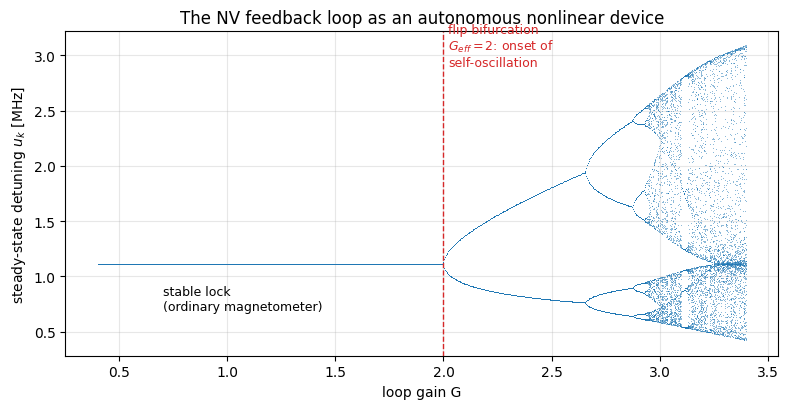

In [8]:
Gs = np.linspace(0.4, 3.4, 800)
fig, ax = plt.subplots(figsize=(8, 4.2))
for G in Gs:
    tail = orbit(G, 500)[-60:]
    ax.plot([G] * len(tail), tail, ",", color="C0", alpha=0.5)
ax.axvline(2.0, color="C3", ls="--", lw=1)
ax.annotate("flip bifurcation\n$G_{eff}=2$: onset of\nself-oscillation",
            (2.02, 2.9), color="C3", fontsize=9)
ax.annotate("stable lock\n(ordinary magnetometer)", (0.7, 0.7), fontsize=9)
ax.annotate("period doubling\n-> chaos", (2.75, 4.4), fontsize=9)
ax.set(xlabel="loop gain G", ylabel="steady-state detuning $u_k$ [MHz]",
       title="The NV feedback loop as an autonomous nonlinear device")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Gain tracks the influence of perturbations
The value of G for which the oscillatory behaviour appears is determined by external perturbation such as microwave power or background magnetic field magnitude. This figure shows the oscillation amplitude against G, for different linewidths of the PL resonance (left) and the gain at which the oscillaitons begin for each linewidth.

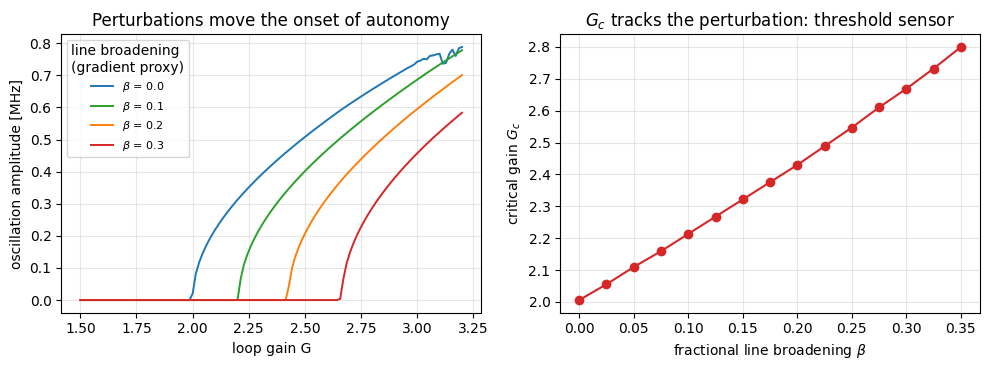

In [9]:
betas = (0.0, 0.1, 0.2, 0.3)
Gs3 = np.linspace(1.5, 3.2, 120)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for b, c in zip(betas, ("C0", "C2", "C1", "C3")):
    amp = [np.mean([orbit_amp(G, beta=b) for _ in range(1)]) for G in Gs3]
    ax.plot(Gs3, amp, color=c, lw=1.4, label=rf"$\beta$ = {b:.1f}")
ax.set(xlabel="loop gain G", ylabel="oscillation amplitude [MHz]",
       title="Perturbations move the onset of autonomy")
ax.legend(title="line broadening\n(gradient proxy)", fontsize=8)
ax.grid(alpha=0.3)

# threshold vs beta: smallest G with amplitude above a small cut
G_fine = np.linspace(1.6, 3.4, 400)
bet_fine = np.linspace(0, 0.35, 15)
thr = []
for b in bet_fine:
    a = np.array([orbit_amp(G, beta=b) for G in G_fine])
    idx = np.argmax(a > 0.05)
    thr.append(G_fine[idx] if a[idx] > 0.05 else np.nan)
ax2.plot(bet_fine, thr, "o-", color="C3")
ax2.set(xlabel=r"fractional line broadening $\beta$",
        ylabel="critical gain $G_c$",
        title=r"$G_c$ tracks the perturbation: threshold sensor")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Experimental results

Using our setup, we performed an experiment to test some of these concepts. First, we define the plotting and data processing functions

In [ ]:
import csv
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np

_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
sys.path.insert(0, os.path.join(_ROOT, "smcv"))
from expconfig import load_config
from odmr_selfosc_fm_pc import alt_amp
from odmr_sensitivity_fm_pc import moving_average, welch_asd

_cfg = load_config()
DEFAULT_DIR = _cfg["paths"]["data_dir"]


# --------------------------------------------------------------------------
def _num(s):
    try:
        float(s)
        return True
    except ValueError:
        return False


def load_gainscan(path):
    """Returns (meta, dict gain -> f array [MHz])."""
    with open(path) as f:
        header = f.readline()
    meta = {}
    for key in ("f_star_MHz", "R0_V", "D_V_per_MHz"):
        mt = re.search(rf"{key}=([0-9eE+.-]+)", header)
        if not mt:
            raise SystemExit(f"Header of {path} is missing '{key}'.")
        meta[key] = float(mt.group(1))
    runs = {}
    with open(path) as f:
        for row in csv.reader(f):
            if not row or row[0].startswith("#") or not _num(row[0]):
                continue
            runs.setdefault(float(row[0]), []).append(float(row[3]))
    return meta, {g: np.array(v) for g, v in sorted(runs.items())}


def load_two_col(path):
    a, b = [], []
    with open(path) as f:
        for row in csv.reader(f):
            if not row or row[0].startswith("#") or not _num(row[0]):
                continue
            a.append(float(row[0]))
            b.append(float(row[1]))
    return np.array(a), np.array(b)


def load_stats(path):
    t, fr = [], []
    with open(path) as f:
        header = f.readline()
    mt = re.search(r"gain=([0-9eE+.-]+)", header)
    g_stat = float(mt.group(1)) if mt else float("nan")
    with open(path) as f:
        for row in csv.reader(f):
            if not row or row[0].startswith("#") or not _num(row[0]):
                continue
            t.append(float(row[1]))
            fr.append(float(row[2]))
    return g_stat, np.array(t), np.array(fr)


# --------------------------------------------------------------------------
def analyse_gainscan(gains_f, skip_frac=0.33):
    """Per-gain tail statistics -> (gains, spread, a2, G_c, dG_c)."""
    gains = np.array(sorted(gains_f))
    spread, a2 = [], []
    for g in gains:
        tail = gains_f[g][int(len(gains_f[g]) * skip_frac):]
        spread.append(float(np.std(tail)))
        a2.append(alt_amp(tail))
    spread, a2 = np.array(spread), np.array(a2)

    # G_c: first crossing of the period-2 amplitude above a threshold set by
    # the sub-threshold baseline (4x the median of the lowest three gains)
    base = float(np.median(a2[:3]))
    thr = max(4 * base, 0.05)
    above = a2 > thr
    if not above.any():
        return gains, spread, a2, float("nan"), float("nan"), thr
    i = int(np.argmax(above))
    if i == 0:
        return gains, spread, a2, float(gains[0]), 0.0, thr
    # linear interpolation of the crossing + half grid spacing as uncertainty
    g_c = float(np.interp(thr, [a2[i - 1], a2[i]], [gains[i - 1], gains[i]]))
    dg = 0.5 * float(gains[i] - gains[i - 1])
    return gains, spread, a2, g_c, dg, thr


def supercritical_gc(gains, a2, thr):
    """Refined G_c: fit the supercritical growth law a2^2 = k (G - G_c) to the
    first few points above onset and take the intercept. Needs >= 2 points
    above 2*thr -- EXTEND the gain grid past the shifted onset for perturbed
    runs, or this returns nan. Complements the crossing estimator (which is a
    lower bound under noise: amplified fluctuations trigger it early)."""
    idx = np.where(a2 > 2 * thr)[0][:4]
    if len(idx) < 2:
        return float("nan")
    k, c = np.polyfit(gains[idx], a2[idx] ** 2, 1)
    return float(-c / k) if k > 0 else float("nan")


def fluct_fit(gains, spread, g_c):
    """One-parameter fit of the sub-threshold critical-fluctuation law
    spread = s0 * sqrt(G / (2 - G)) (uses points safely below threshold)."""
    m = gains < min(g_c - 0.15, 1.95) if np.isfinite(g_c) else gains < 1.95
    if m.sum() < 2:
        return None, None
    shape = np.sqrt(gains[m] / (2.0 - gains[m]))
    s0 = float(np.sum(spread[m] * shape) / np.sum(shape ** 2))
    gg = np.linspace(gains[0], 1.98, 200)
    return gg, s0 * np.sqrt(gg / (2.0 - gg))


def true_slope_from_spectrum(spec_path, f_star, R0):
    """Slope that actually governs the loop dynamics: the LOCAL slope at the
    FIXED POINT, i.e. where the (smoothed) spectrum crosses the setpoint R0
    nearest to f_star, fitted over a narrow +/-3-point window (a wide window
    dilutes the slope and would bias the collapse)."""
    freqs, R = load_two_col(spec_path)
    Rs = moving_average(R, 3)
    best = None
    for i in range(2, len(freqs) - 3):
        if (Rs[i] - R0) * (Rs[i + 1] - R0) <= 0:
            d = abs(freqs[i] - f_star)
            if best is None or d < best[0]:
                best = (d, i)
    i = best[1] if best else int(np.argmin(np.abs(freqs - f_star)))
    lo, hi = max(0, i - 3), min(len(freqs), i + 4)
    slope, _ = np.polyfit(freqs[lo:hi], R[lo:hi], 1)
    return float(slope)


# --------------------------------------------------------------------------
def plot_run(run_dir):
    gs_path = os.path.join(run_dir, "selfosc_fm_gainscan.csv")
    meta, runs = load_gainscan(gs_path)
    gains, spread, a2, g_c, dg, thr = analyse_gainscan(runs)
    g_fit = supercritical_gc(gains, a2, thr)
    print(f"[{run_dir}]  G_c = {g_c:.2f} +/- {dg:.2f} (crossing), "
          f"{g_fit:.2f} (supercritical fit)  "
          f"(D_cal = {meta['D_V_per_MHz'] * 1e3:+.3f} mV/MHz)")

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    # (a) measured bifurcation diagram
    ax = axes[0, 0]
    for g in gains:
        tail = runs[g][int(len(runs[g]) * 0.33):]
        ax.plot([g] * len(tail), tail, ".", ms=2, color="tab:blue", alpha=0.25)
    if np.isfinite(g_c):
        ax.axvline(g_c, color="tab:red", ls="--", lw=1.2,
                   label=f"$G_c$ = {g_c:.2f} $\\pm$ {dg:.2f}")
        ax.legend(fontsize=8)
    ax.set_xlabel("loop gain G")
    ax.set_ylabel("orbit frequency (MHz)")
    ax.set_title("(a) Measured bifurcation diagram")
    ax.grid(alpha=0.3)

    # (b) spread + period-2 amplitude vs gain
    ax = axes[0, 1]
    ax.semilogy(gains, 1e3 * spread, "s-", color="tab:orange",
                label="orbit spread (incl. critical fluctuations)")
    ax.semilogy(gains, 1e3 * np.maximum(a2, 1e-4), "o-", color="tab:blue",
                label="coherent period-2 amplitude")
    gg, fit = fluct_fit(gains, spread, g_c)
    if gg is not None:
        ax.semilogy(gg, 1e3 * fit, "--", color="tab:orange", alpha=0.7,
                    label=r"$\propto\sqrt{G/(2-G)}$ precursor fit")
    ax.axhline(1e3 * thr, color="tab:blue", ls=":", lw=1, alpha=0.7)
    if np.isfinite(g_c):
        ax.axvline(g_c, color="tab:red", ls="--", lw=1)
    ax.set_xlabel("loop gain G")
    ax.set_ylabel("amplitude (kHz)")
    ax.set_title("(b) Onset and its precursor")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, which="both")

    # (c) example orbits
    ax = axes[1, 0]
    picks = [gains[0], gains[len(gains) // 2], gains[-1]]
    if np.isfinite(g_c):
        picks[1] = float(gains[np.argmin(np.abs(gains - (g_c + 0.15)))])
    for k, g in enumerate(picks):
        y = runs[g][-120:]
        ax.plot(np.arange(len(y)), y - np.mean(y) + k * 1.2, lw=0.8,
                label=f"G = {g:g}")
    ax.set_xlabel("loop cycle")
    ax.set_ylabel("frequency, offset per trace (MHz)")
    ax.set_title("(c) Orbits: lock / limit cycle / deep")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # (d) demodulated cycle spectrum of the statistics run
    ax = axes[1, 1]
    st_path = os.path.join(run_dir, "selfosc_fm_stats.csv")
    if os.path.exists(st_path):
        g_stat, t, fr_ = load_stats(st_path)
        dt = float(np.median(np.diff(t)))
        s = ((-1.0) ** np.arange(len(fr_))) * (fr_ - np.mean(fr_))
        fr_psd, asd = welch_asd(s, dt)
        ax.semilogy(fr_psd[1:], 1e3 * asd[1:], lw=1.0, color="tab:blue")
        ax.set_title(f"(d) Cycle spectrum, G = {g_stat:g} "
                     "(AC signals appear as sidebands)")
        ax.set_xlabel("frequency (Hz)")
        ax.set_ylabel(r"demodulated amplitude (kHz/$\sqrt{Hz}$)")
    else:
        ax.set_title("(d) no selfosc_fm_stats.csv found")
    ax.grid(alpha=0.3, which="both")

    fig.suptitle(f"NV self-oscillation gain scan -- {run_dir}", y=0.995)
    fig.tight_layout()
    out = os.path.join(run_dir, "selfosc_fm.png")
    fig.savefig(out, dpi=150)
    print(f"Saved {out}")
    return meta, g_c, dg, g_fit


def plot_collapse(run_dirs, results):
    """G_c vs the theory prediction 2*|D_cal|/|D_true| across runs."""
    xs, ys, dys, yfits, labels = [], [], [], [], []
    for run_dir, (meta, g_c, dg, g_fit) in zip(run_dirs, results):
        spec = os.path.join(run_dir, "selfosc_fm_spectrum.csv")
        if not (os.path.exists(spec) and np.isfinite(g_c)):
            continue
        d_true = true_slope_from_spectrum(spec, meta["f_star_MHz"],
                                          meta["R0_V"])
        xs.append(2.0 * abs(meta["D_V_per_MHz"]) / abs(d_true))
        ys.append(g_c)
        dys.append(dg)
        yfits.append(g_fit)
        labels.append(os.path.basename(os.path.normpath(run_dir)))
    if len(xs) < 2:
        print("collapse plot: need >= 2 runs with spectra and a finite G_c")
        return
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    ax.errorbar(xs, ys, yerr=dys, fmt="o", ms=7, color="tab:blue", capsize=3,
                label="crossing estimator (lower bound)")
    yf = np.array(yfits)
    mfin = np.isfinite(yf)
    if mfin.any():
        ax.plot(np.array(xs)[mfin], yf[mfin], "o", ms=9, mfc="none",
                color="tab:green", label="supercritical fit")
    for x, y, lb in zip(xs, ys, labels):
        ax.annotate(lb, (x, y), textcoords="offset points", xytext=(6, 4),
                    fontsize=8)
    lim = [0.9 * min(xs + ys), 1.1 * max(xs + ys)]
    ax.plot(lim, lim, "--", color="0.5", label="theory: $G_c = 2\\,D_{cal}/D_{true}$")
    # note: the crossing estimator triggers early under noise (amplified
    # critical fluctuations), so points sit slightly BELOW the identity line;
    # the supercritical fit corrects this when the grid extends past onset
    ax.set_xlabel(r"predicted $2\,|D_{cal}|/|D_{true}|$")
    ax.set_ylabel(r"measured critical gain $G_c$")
    ax.set_title("Onset collapse across perturbations")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    out = os.path.join(run_dirs[0], "selfosc_collapse.png")
    fig.savefig(out, dpi=150)
    print(f"Saved {out}")

##dffff

In [ ]:
run_dirs = sys.argv[1:] if len(sys.argv) > 1 else [DEFAULT_DIR]
results = [plot_run(d) for d in run_dirs]
if len(run_dirs) > 1:
    plot_collapse(run_dirs, results)
plt.show()

## Limitations

For Gaussian-noise-limited estimation of a *small analog* signal, a well-designed
linear readout with matched filtering is asymptotically optimal; the autonomous
mode does not beat it in raw SNR. Its advantages are of a different kind:
threshold/latching detection (binary output robust to gain and contrast drift),
symmetry-enforced selectivity to differential quantities, internal frequency
conversion of AC signals, and — scientifically — a table-top platform where the
sensing-through-bifurcation concepts of the proposal can be tested and
benchmarked against the same team's NV expertise before being deployed on
mesoscopic autonomous devices.
